In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("train.csv")

In [3]:
print("Training Data: ",df.shape)

Training Data:  (1460, 81)


In [4]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
df.drop('Id', axis=1, inplace=True)

In [6]:
null = df.isnull().mean()
cols_with_45_null = null[(null >= 0.45)]
print(cols_with_45_null)


Alley          0.937671
MasVnrType     0.597260
FireplaceQu    0.472603
PoolQC         0.995205
Fence          0.807534
MiscFeature    0.963014
dtype: float64


In [7]:
df.drop(df[['PoolQC','MiscFeature','Alley','Fence','MasVnrType','FireplaceQu']], axis = 1, inplace = True, errors= False)

In [8]:
df.isnull().sum().sort_values(ascending = False)

LotFrontage     259
GarageYrBlt      81
GarageCond       81
GarageType       81
GarageFinish     81
               ... 
BsmtUnfSF         0
TotalBsmtSF       0
Heating           0
MSZoning          0
SalePrice         0
Length: 74, dtype: int64

In [9]:
cat_data = df.select_dtypes(exclude= "number")
num_data = df.select_dtypes(include = "number")

In [10]:
def fill_missing(df, cat_cols, num_cols):
    for col in cat_cols:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].mode()[0])
    for col in num_cols:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].median())
    return df

df = fill_missing(df, cat_data,num_data)

In [11]:
df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,12,2008,WD,Normal,250000


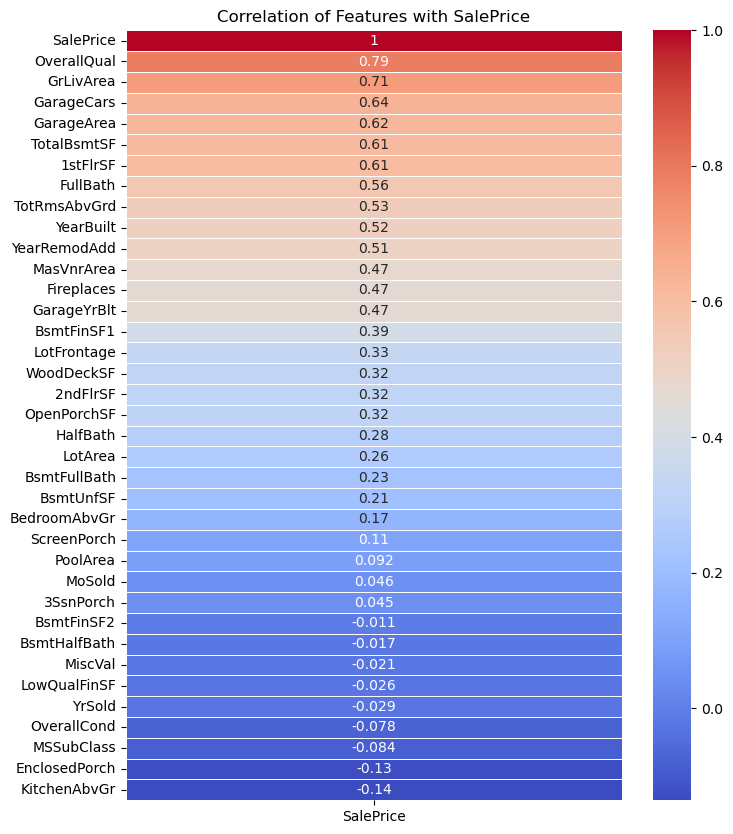

In [12]:
corr_matrix = df.corr(numeric_only=True)

salesprice_corr = corr_matrix[['SalePrice']].sort_values(by='SalePrice', ascending=False)

plt.figure(figsize=(8, 10))
sns.heatmap(salesprice_corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation of Features with SalePrice')
plt.show()

In [13]:
df = df.drop(columns=df[[
    'BsmtFinSF2',
    'BsmtHalfBath',
    'MiscVal',
    'LowQualFinSF',
    'YrSold',
    'OverallCond',
    'MSSubClass',
    'EnclosedPorch',
    'KitchenAbvGr'
]])


In [14]:
test_df = pd.read_csv("cleaned_test.csv")

In [15]:
test_df

,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,3SsnPorch,ScreenPorch,PoolArea,MoSold,SaleType,SaleCondition
0,RH,80.0,11622,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,...,TA,Y,140,0,0,120,0,6,WD,Normal
1,RL,81.0,14267,Pave,IR1,Lvl,AllPub,Corner,Gtl,NAmes,...,TA,Y,393,36,0,0,0,6,WD,Normal
2,RL,74.0,13830,Pave,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,...,TA,Y,212,34,0,0,0,3,WD,Normal
3,RL,78.0,9978,Pave,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,...,TA,Y,360,36,0,0,0,6,WD,Normal
4,RL,43.0,5005,Pave,IR1,HLS,AllPub,Inside,Gtl,StoneBr,...,TA,Y,0,82,0,144,0,1,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,RM,21.0,1936,Pave,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,...,TA,Y,0,0,0,0,0,6,WD,Normal
1455,RM,21.0,1894,Pave,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,...,TA,Y,0,24,0,0,0,4,WD,Abnorml
1456,RL,160.0,20000,Pave,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,...,TA,Y,474,0,0,0,0,9,WD,Abnorml
1457,RL,62.0,10441,Pave,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,...,TA,Y,80,32,0,0,0,7,WD,Normal


In [16]:
df

,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,PavedDrive,WoodDeckSF,OpenPorchSF,3SsnPorch,ScreenPorch,PoolArea,MoSold,SaleType,SaleCondition,SalePrice
0,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,...,Y,0,61,0,0,0,2,WD,Normal,208500
1,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,...,Y,298,0,0,0,0,5,WD,Normal,181500
2,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,...,Y,0,42,0,0,0,9,WD,Normal,223500
3,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,...,Y,0,35,0,0,0,2,WD,Abnorml,140000
4,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,...,Y,192,84,0,0,0,12,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,RL,62.0,7917,Pave,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,...,Y,0,40,0,0,0,8,WD,Normal,175000
1456,RL,85.0,13175,Pave,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,...,Y,349,0,0,0,0,2,WD,Normal,210000
1457,RL,66.0,9042,Pave,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,...,Y,0,60,0,0,0,5,WD,Normal,266500
1458,RL,68.0,9717,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,...,Y,366,0,0,0,0,4,WD,Normal,142125


In [17]:
y_train = df["SalePrice"]
df_X = df.drop(["SalePrice"], axis=1)


In [18]:
dataframe = pd.concat([df_X,test_df], axis=0)

In [19]:
X_cat = dataframe.select_dtypes(exclude = "number")
X_num = dataframe.select_dtypes(include = "number")

In [20]:
X_cat = pd.get_dummies(X_cat, drop_first=True, dtype= int)


In [21]:
X = pd.concat([X_cat, X_num], axis = 1)


In [22]:
X

,MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Pave,LotShape_IR2,LotShape_IR3,LotShape_Reg,LandContour_HLS,LandContour_Low,...,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,3SsnPorch,ScreenPorch,PoolArea,MoSold
0,0,0,1,0,1,0,0,1,0,0,...,0,2003.0,2.0,548.0,0,61,0,0,0,2
1,0,0,1,0,1,0,0,1,0,0,...,1,1976.0,2.0,460.0,298,0,0,0,0,5
2,0,0,1,0,1,0,0,0,0,0,...,1,2001.0,2.0,608.0,0,42,0,0,0,9
3,0,0,1,0,1,0,0,0,0,0,...,1,1998.0,3.0,642.0,0,35,0,0,0,2
4,0,0,1,0,1,0,0,0,0,0,...,1,2000.0,3.0,836.0,192,84,0,0,0,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,0,0,0,1,1,0,0,1,0,0,...,0,1979.0,0.0,0.0,0,0,0,0,0,6
1455,0,0,0,1,1,0,0,1,0,0,...,0,1970.0,1.0,286.0,0,24,0,0,0,4
1456,0,0,1,0,1,0,0,1,0,0,...,1,1960.0,2.0,576.0,474,0,0,0,0,9
1457,0,0,1,0,1,0,0,1,0,0,...,0,1979.0,0.0,0.0,80,32,0,0,0,7


In [23]:
X_train = X[:1460]
X_test = X[1460:]

In [24]:
print(X_train.shape,X_test.shape,y_train.shape)

(1460, 220) (1459, 220) (1460,)


## Linear Regression

In [25]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

In [26]:
model = LinearRegression() # model initialization 
model.fit(X_train,y_train) #fitting training data

LinearRegression()

In [27]:
test_predictions = model.predict(X_test)

In [28]:
test_predictions

array([112826.62256513, 164924.55775995, 189526.52954505, ...,
       174991.44235019, 104381.07994594, 220877.56864137])

In [29]:
train_predictions = model.predict(X_train)

In [30]:
# print("Test Mean Squared Error:", mean_squared_error(y_test, test_predictions))
print("Train Mean Squared Error:", mean_squared_error(y_train, train_predictions))
# print("Test R2 Score:", r2_score(y_test, test_predictions)*100)
print("Train R2 Score:", r2_score(y_train, train_predictions)*100)

Train Mean Squared Error: 458333198.32831967
Train R2 Score: 92.73270076956392


## Ridge Model

In [31]:
ridge_model = Ridge(alpha = 0.01)  # model initialization
ridge_model.fit(X_train,y_train) # model training

Ridge(alpha=0.01)

In [32]:
ridge_test = ridge_model.predict(X_test)
ridge_train = ridge_model.predict(X_train)

In [33]:
print("Ridge Model MSE of Train: ",mean_squared_error(y_train,ridge_train))
# print("Ridge Model MSE of Test: ",mean_squared_error(y_test,ridge_test))
# print("Test R2 Score:", r2_score(y_test, ridge_test)*100)
print("Train R2 Score:", r2_score(y_train, ridge_train)*100)

Ridge Model MSE of Train:  461159009.70576304
Train R2 Score: 92.68789490142356


## Lasso Model

In [34]:
Lasso_model = Lasso(alpha = 0.01)
Lasso_model.fit(X_train,y_train)

C:\Users\sachi\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.347e+11, tolerance: 9.208e+08
  model = cd_fast.enet_coordinate_descent(


Lasso(alpha=0.01)

In [35]:
Lasso_test = Lasso_model.predict(X_test)
Lasso_train = Lasso_model.predict(X_train)

In [36]:
print("Lasso Model MSE of Train: ",mean_squared_error(y_train,Lasso_train))
# print("Lasso Model MSE of Test: ",mean_squared_error(y_test,Lasso_test))
print("Lasso Model Train R^2 value: ",r2_score(y_train,Lasso_train)*100)
# print("Lasso Model Test R^2 value: ",r2_score(y_test,Lasso_test)*100)

Lasso Model MSE of Train:  458335354.52811456
Lasso Model Train R^2 value:  92.73266658101035


In [37]:
pred = pd.DataFrame(test_predictions,columns = ['SalePrice'])
sample_df = pd.read_csv('sample_submission.csv')
dataset = pd.concat([sample_df['Id'],pred], axis = 1)
dataset.to_csv('submission.csv',index = False)

In [38]:
len(test_predictions)

1459